In [ ]:
import os, sys
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
sys.path.insert(0, parent_dir)
from src.plotting.visutil import CSVPlotter
import pandas as pd
pjoin = os.path.join
%load_ext autoreload
%autoreload 2

NameError: name '__file__' is not defined

In [2]:
training_dir = '/Users/yuntongzhou/Desktop/Dihiggszztt/output/training'
dfD = pd.read_csv(pjoin(training_dir,'NN_RegionD.csv'), index_col=0)
dfB = pd.read_csv(pjoin(training_dir,'NN_RegionB.csv'), index_col=0)
dfA = pd.read_csv(pjoin(training_dir, "RegionA.csv"), index_col=0)
dfC = pd.read_csv(pjoin(training_dir, "RegionC.csv"), index_col=0)

/var/folders/w4/tl7q52611yg4x42kkpb7bm0m0000gn/T/ipykernel_29035/2254069856.py:2: DtypeWarning: Columns (51,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  dfD = pd.read_csv(pjoin(training_dir,'NN_RegionD.csv'), index_col=0)
/var/folders/w4/tl7q52611yg4x42kkpb7bm0m0000gn/T/ipykernel_29035/2254069856.py:3: DtypeWarning: Columns (51,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  dfB = pd.read_csv(pjoin(training_dir,'NN_RegionB.csv'), index_col=0)


In [3]:
ori_dfD = pd.read_csv(pjoin(training_dir, "RegionD.csv"))
ori_dfB = pd.read_csv(pjoin(training_dir, "RegionB.csv"))

## Plot

In [5]:
def plot_vars_one_figure(ori_dfD, dfD, dfC, ori_dfB, dfB, dfA, att):
    training_dir = '/Users/yuntongzhou/Desktop/Dihiggszztt/output/training'
    cp = CSVPlotter(pjoin(training_dir, 'plots'))
    cp.plot_shape([dfC, ori_dfD, dfD], ['Region C (2b)', 'Original Region D(1b)', 'Reweighted Region D'], att, 'prediction/data', pjoin(training_dir, 'plots'), 
                title='SS Control Region', save_suffix='CD')
    cp.plot_shape([dfA, ori_dfB, dfB], ['Region A (2b)', 'Original Region B(1b)', 'Reweighted Region B'], att, 'prediction/data', pjoin(training_dir, 'plots'), 
                title='OS Control Region', save_suffix='AB')

In [6]:
from config.plotsetting import H_mass, dR

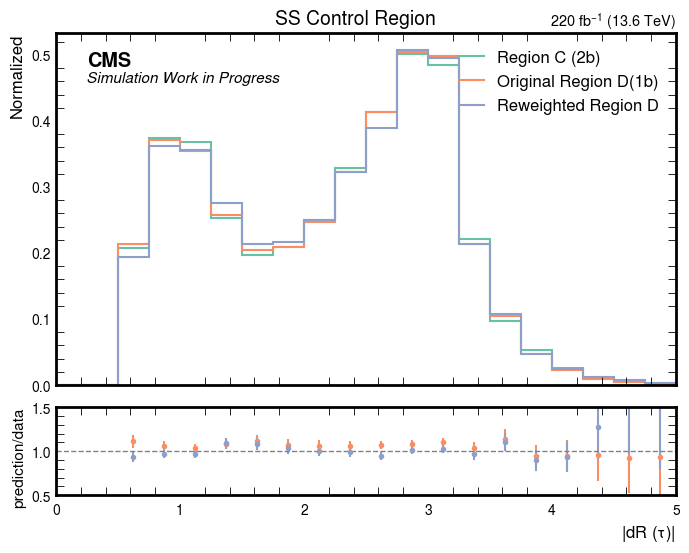

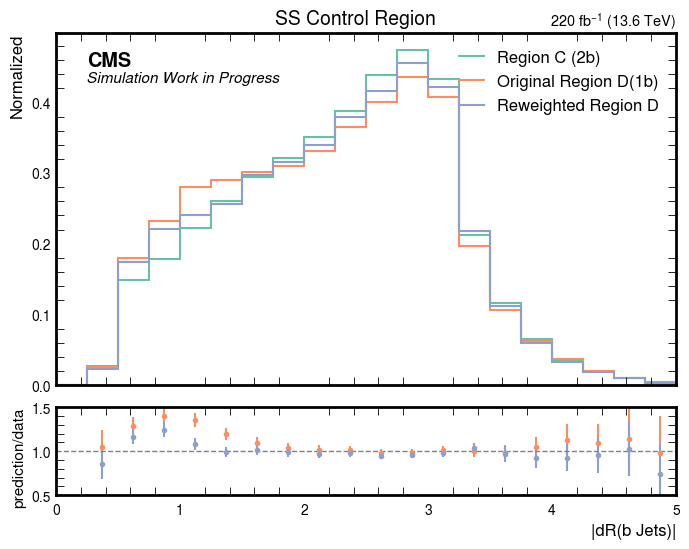

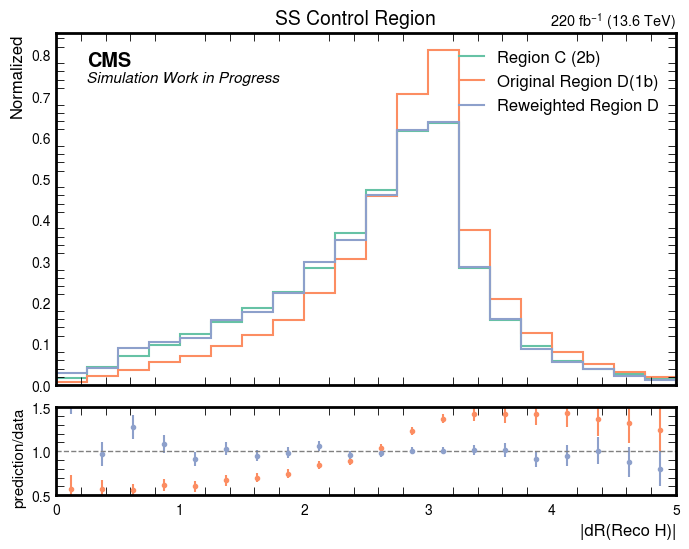

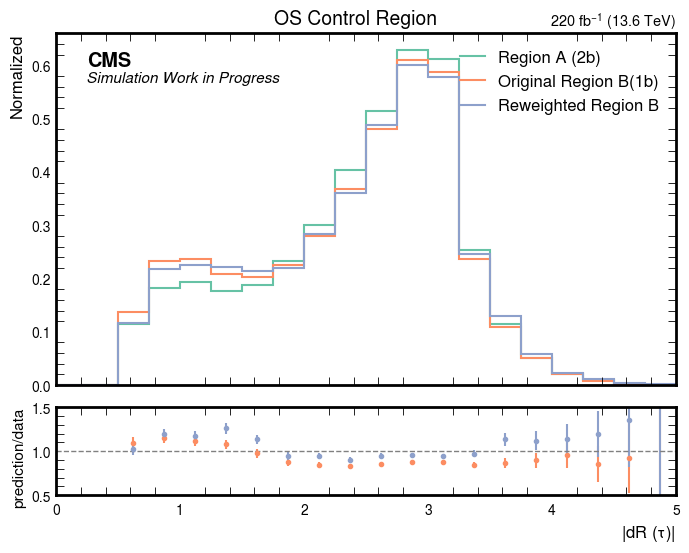

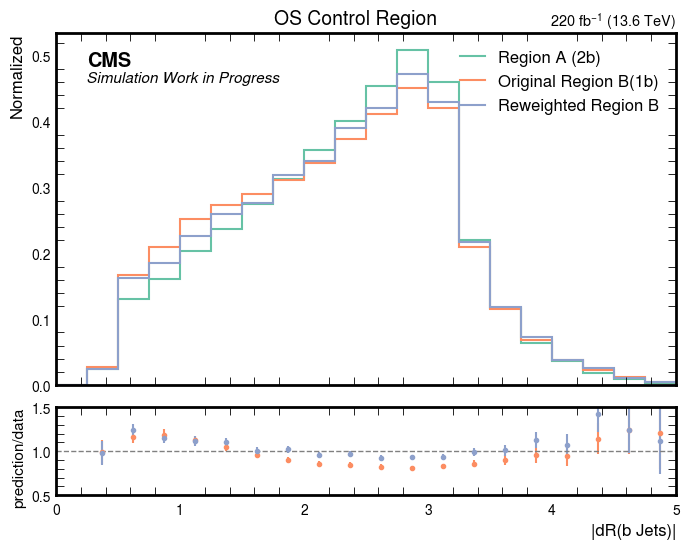

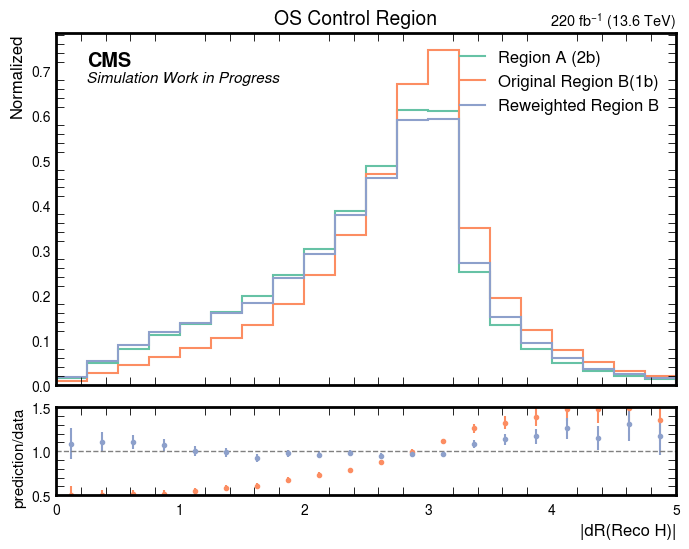

In [7]:
plot_vars_one_figure(ori_dfD, dfD, dfC, ori_dfB, dfB, dfA, dR)

In [ ]:
plot_vars(ori_dfD, dfD, dfC, ori_dfB, dfB, dfA, dR)

## Train a second BDT

In [28]:
from src.learning.reweight import *
original = dfD.copy()
target = dfC.copy()
results_dir = "/Users/yuntongzhou/Desktop/Dihiggszztt/output"
drop_kwds = ['Gen', 'weight_values', 'OS', 'group', 'gen', 'dataset', 'weight', 'label', 'btag']
rwgter = SingleXGBReweighter(original, target, 'weight', results_dir)
rwgter.prep_data(drop_kwds)
rwgter.boostingSearch(10, 600, seed=10)

Dropped  393  events with negative weights out of  89884  events.
Dropped  415  events with negative weights out of  82535  events.
[0]	train-logloss:0.68417+0.00028	test-logloss:0.68915+0.00077
[20]	train-logloss:0.60396+0.00099	test-logloss:0.68284+0.00438
[32]	train-logloss:0.57939+0.00090	test-logloss:0.68596+0.00580
Optimal number of boosting rounds: 13


In [29]:
rwgter.train()

[0]	train-logloss:0.68438	test-logloss:0.70118
[12]	train-logloss:0.63096	test-logloss:0.71504


In [30]:
rwgter.evaluate()

Accuracy:  0.6197070934659311
ROC AUC Score:  0.6721652903483408


In [31]:
norm_C = dfC['weight'].sum()
norm_A = dfA['weight'].sum()
rwgt_D = rwgter.reweight(dfD, norm_C, drop_kwds, True, pjoin(training_dir,'Rewgt_RegionD_2.csv'))
rwgt_B = rwgter.reweight(dfB, norm_A, drop_kwds, True, pjoin(training_dir,'Rewgt_RegionB_2.csv'))

Dropped  393  events with negative weights out of  89884  events.
Dropped  726  events with negative weights out of  162811  events.


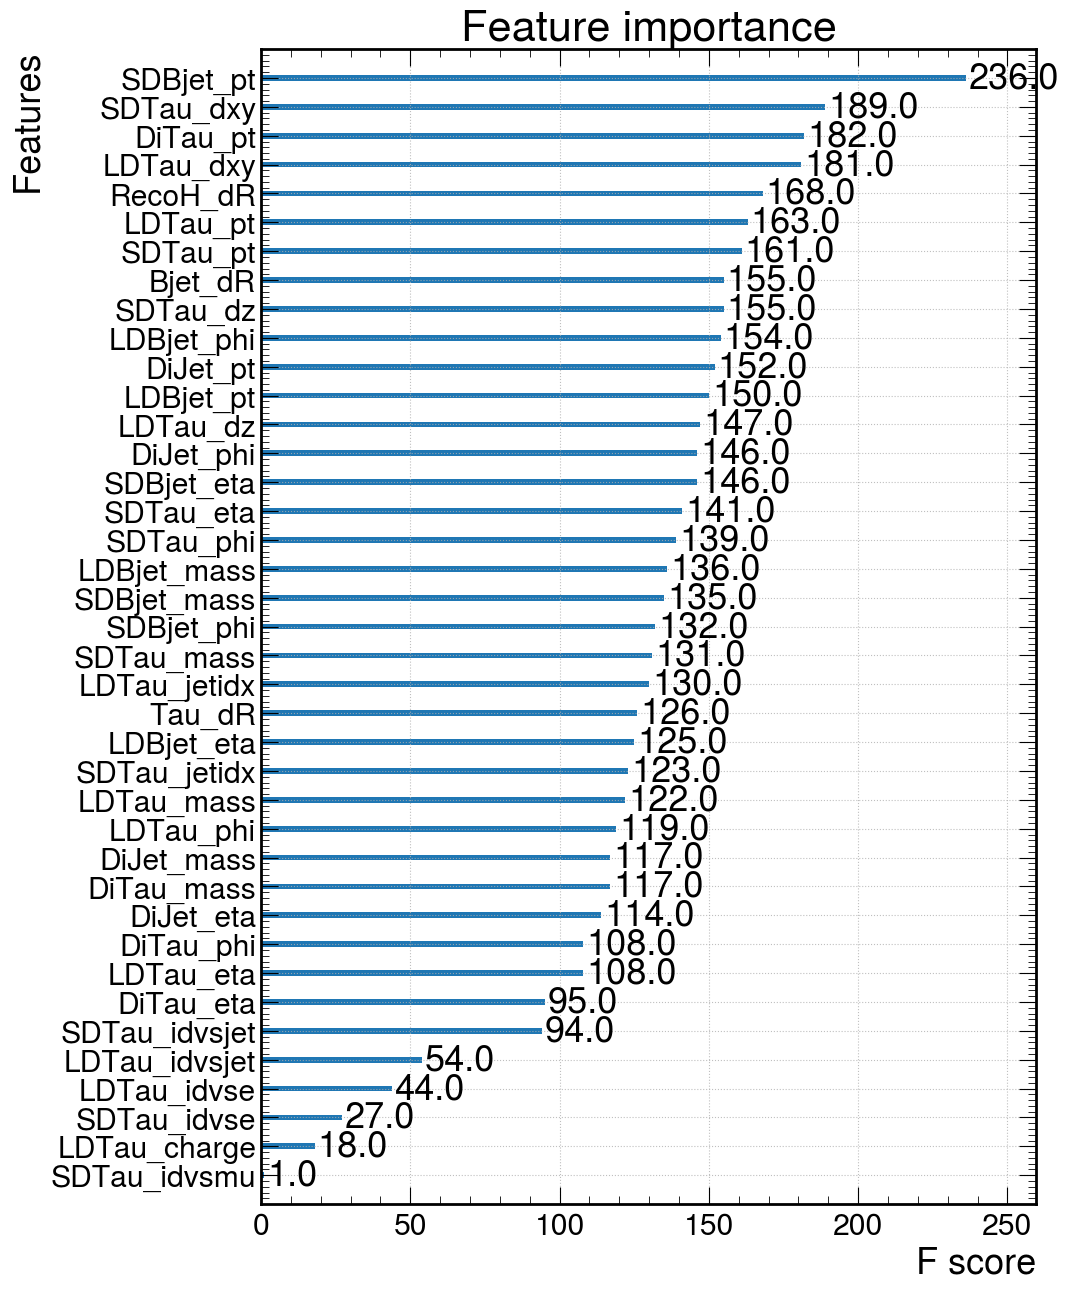

In [32]:
# Visualize the trained BDT discriminator
xgb.plot_importance(rwgter._model)
plt.gcf().set_size_inches(10, 15)
plt.show()

## Plot Reweighted

In [9]:
from config.plotsetting import H_mass, dR

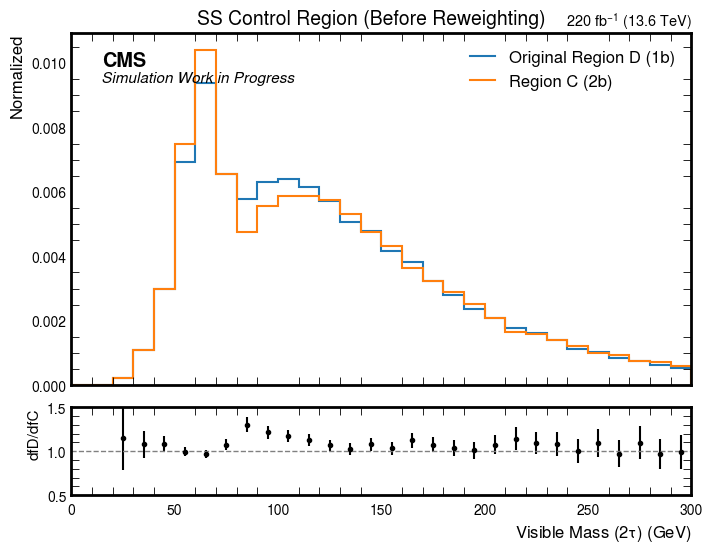

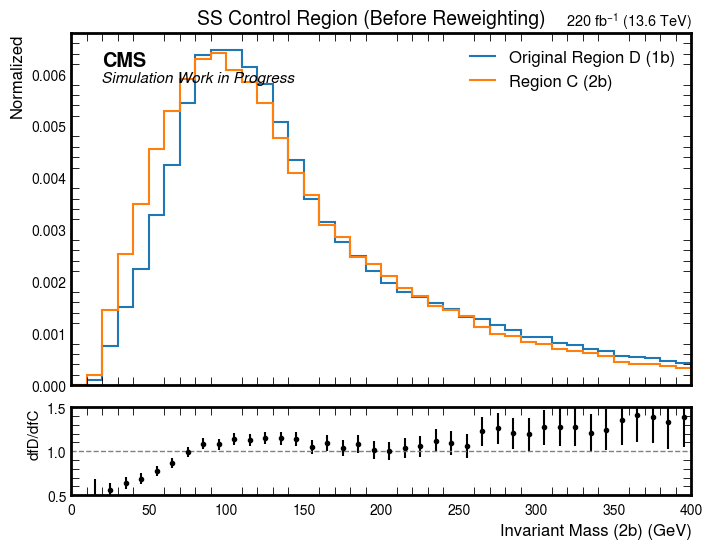

In [52]:
cp.plot_shape([ori_dfD, dfC], ['Original Region D(1b)', 'Region C (2b)'], H_mass, 'dfD/dfC', pjoin(training_dir, 'plots'), 
                           title='SS Control Region (Before Reweighting)', save_suffix='oriCD')

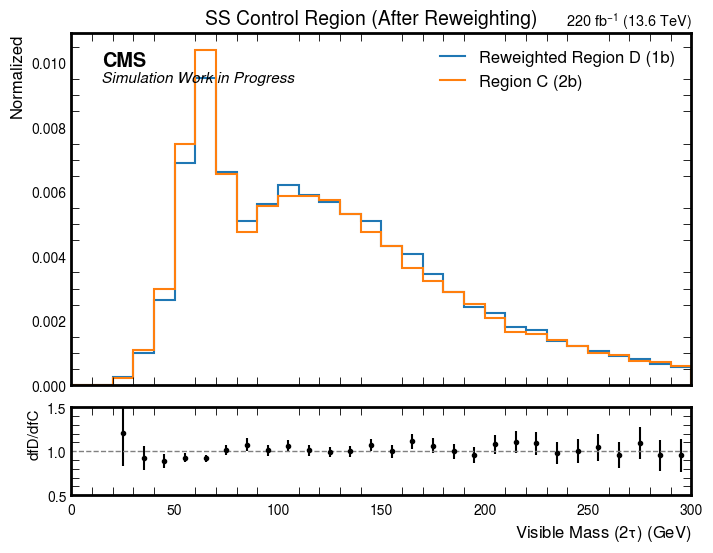

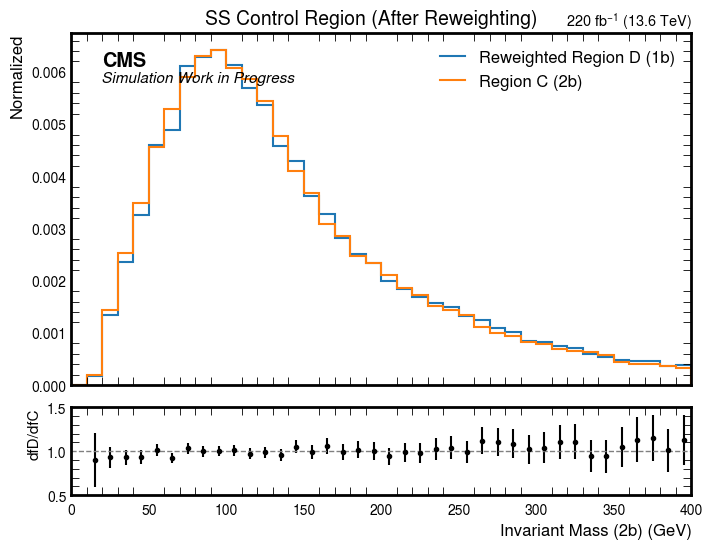

In [51]:
cp.plot_shape([dfD, dfC], ['Reweighted Region D (1b)', 'Region C (2b)'], H_mass, 'dfD/dfC', pjoin(training_dir, 'plots'), 
                           title='SS Control Region (After Reweighting)', save_suffix='rwgtCD')

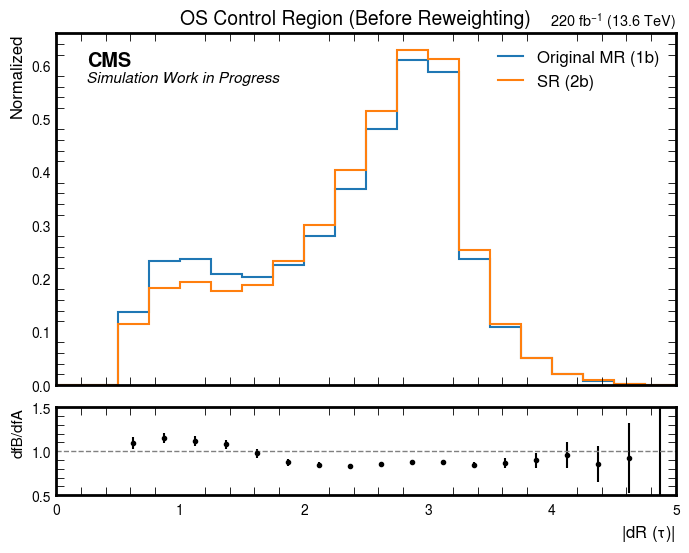

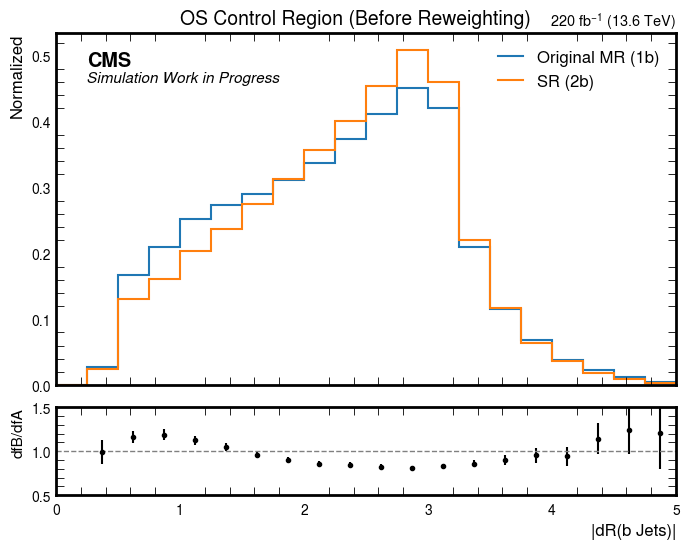

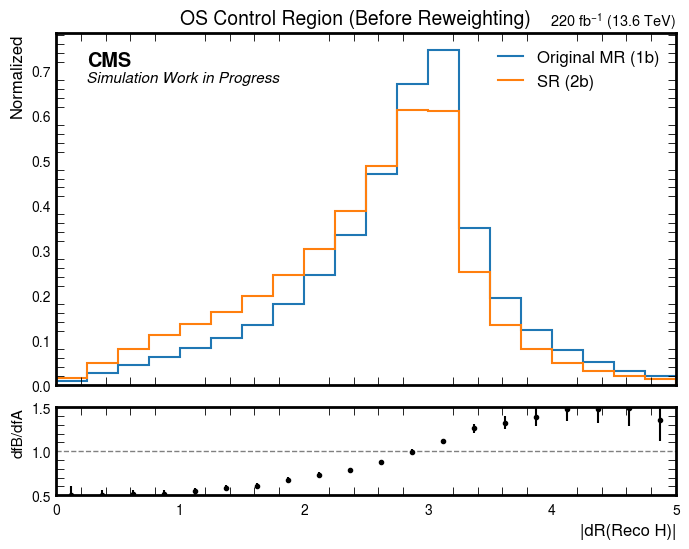

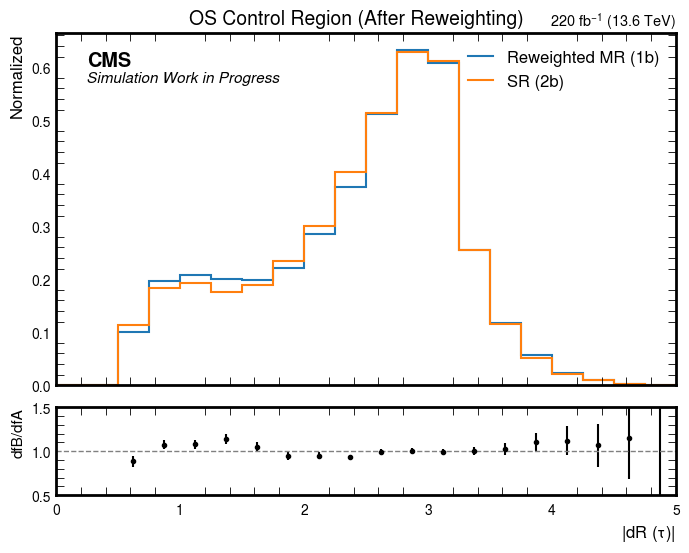

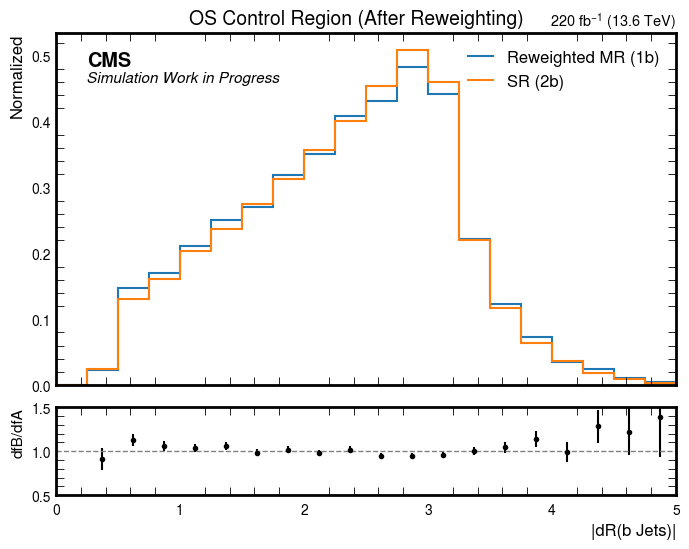

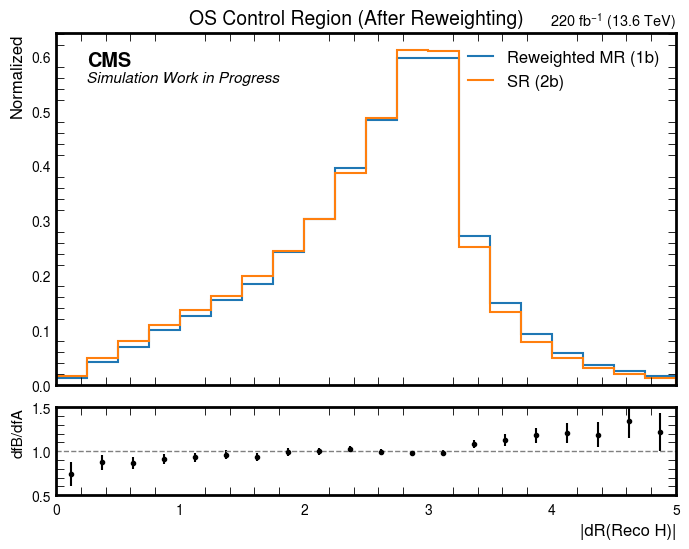

In [10]:
cp.plot_shape([ori_dfB, dfA], ['Original MR (1b)', 'SR (2b)'], dR, 'dfB/dfA', pjoin(training_dir, 'plots'), 
                           title='OS Control Region (Before Reweighting)', save_suffix='oriAB')
cp.plot_shape([dfB, dfA], ['Reweighted MR (1b)', 'SR (2b)'], dR, 'dfB/dfA', pjoin(training_dir, 'plots'), 
                           title='OS Control Region (After Reweighting)', save_suffix='rwgtAB')